<a href="https://colab.research.google.com/github/ZukaCS/ML_FINAL_PROJECT/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import pandas as pd

# Mount Drive (for kaggle.json + persistence)
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/data")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile

zip_path = PROJECT_DIR / "walmart-recruiting-store-sales-forecasting.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(PROJECT_DIR)

In [3]:
train = pd.read_csv(PROJECT_DIR / "train.csv.zip")
test = pd.read_csv(PROJECT_DIR / "test.csv.zip")
features = pd.read_csv(PROJECT_DIR / "features.csv.zip")
stores = pd.read_csv(PROJECT_DIR / "stores.csv")
sample_submission = pd.read_csv(PROJECT_DIR / "sampleSubmission.csv.zip")

In [4]:
print(f"train shape: {train.shape}")
print(train.dtypes)
train.head()

train shape: (421570, 5)
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
print(f"test shape: {test.shape}")
test.head()

test shape: (115064, 4)


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [6]:
print(f"features shape: {features.shape}")
features.head()

features shape: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
print(f"stores shape: {stores.shape}")
stores.head()

stores shape: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [8]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

##### Here we compare train and test dates. test dates come after train dates

In [9]:
print("Train dates:", train["Date"].min(), "to", train["Date"].max())
print("Test dates:", test["Date"].min(), "to", test["Date"].max())
print("Features dates:", features["Date"].min(), "to", features["Date"].max())

Train dates: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Test dates: 2012-11-02 00:00:00 to 2013-07-26 00:00:00
Features dates: 2010-02-05 00:00:00 to 2013-07-26 00:00:00


In [10]:
df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

print(df.shape) #same as train shape in terms of rows. good
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [12]:
df.isna().mean().sort_values(ascending=False)

,0
MarkDown2,0.736110
MarkDown4,0.679847
MarkDown3,0.674808
MarkDown1,0.642572
MarkDown5,0.640790
Store,0.000000
Date,0.000000
Dept,0.000000
Fuel_Price,0.000000
Temperature,0.000000


## More EDA and graphs

Now I want to look at the data from forecasting point of view. The main things we need before models are:
1. seasonality and holiday behavior
2. which stores/departments are more important
3. how external variables and markdowns behave
4. whether train and test have the same structure


In [13]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except ImportError:
    sns = None
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("ggplot")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

test_df = test.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
test_df = test_df.merge(stores, on="Store", how="left")
test_df["Year"] = test_df["Date"].dt.year
test_df["Month"] = test_df["Date"].dt.month
test_df["Week"] = test_df["Date"].dt.isocalendar().week.astype(int)
test_df["Quarter"] = test_df["Date"].dt.quarter


##### Target distribution
Weekly sales are not normally distributed. There are many small sales values and some very large store-department weeks. This is important because a few high sales departments can dominate the error.


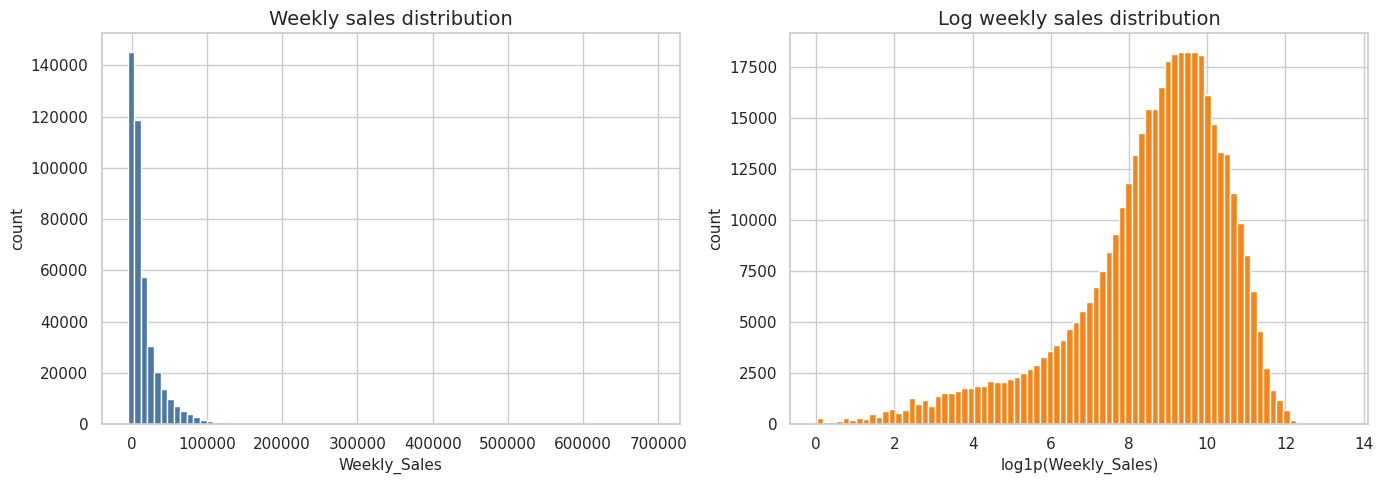

,Weekly_Sales
count,"421,570.00"
mean,"15,981.26"
std,"22,711.18"
min,"-4,988.94"
1%,5.00
5%,59.97
25%,"2,079.65"
50%,"7,612.03"
75%,"20,205.85"
95%,"61,201.95"


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Weekly_Sales"], bins=80, color="#4C78A8", edgecolor="white")
axes[0].set_title("Weekly sales distribution")
axes[0].set_xlabel("Weekly_Sales")
axes[0].set_ylabel("count")

positive_sales = df.loc[df["Weekly_Sales"] > 0, "Weekly_Sales"]
axes[1].hist(np.log1p(positive_sales), bins=80, color="#F58518", edgecolor="white")
axes[1].set_title("Log weekly sales distribution")
axes[1].set_xlabel("log1p(Weekly_Sales)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

df["Weekly_Sales"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])


In [16]:
negative_sales = (df["Weekly_Sales"] < 0).sum()
zero_sales = (df["Weekly_Sales"] == 0).sum()
print(f"Negative sales rows: {negative_sales:,}")
print(f"Zero sales rows: {zero_sales:,}")
print(f"Negative + zero share: {(negative_sales + zero_sales) / len(df):.2%}")


Negative sales rows: 1,285
Zero sales rows: 73
Negative + zero share: 0.32%


##### Negative and zero sales analysis
Negative sales are rare, so on a normal bar chart they are almost invisible compared to positive sales rows. Here I use a log scale only for visualization, so we can still see the small negative/zero groups.


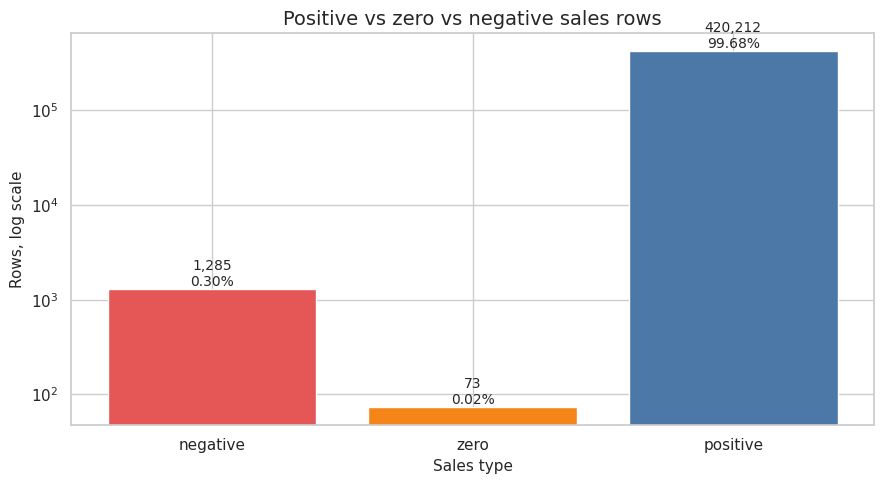

,type,rows,share
0,negative,1285,0.00
1,zero,73,0.00
2,positive,420212,1.00


In [17]:
sales_type_summary = pd.DataFrame({
    "type": ["negative", "zero", "positive"],
    "rows": [
        (df["Weekly_Sales"] < 0).sum(),
        (df["Weekly_Sales"] == 0).sum(),
        (df["Weekly_Sales"] > 0).sum(),
    ]
})
sales_type_summary["share"] = sales_type_summary["rows"] / len(df)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E45756", "#F58518", "#4C78A8"]
bars = ax.bar(sales_type_summary["type"], sales_type_summary["rows"], color=colors)

ax.set_yscale("log")
ax.set_title("Positive vs zero vs negative sales rows")
ax.set_xlabel("Sales type")
ax.set_ylabel("Rows, log scale")

for bar, rows, share in zip(bars, sales_type_summary["rows"], sales_type_summary["share"]):
    label = f"{rows:,}" + chr(10) + f"{share:.2%}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rows,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

sales_type_summary


##### Overall weekly pattern
Here I aggregate all stores and departments by week. We can already see strong seasonality, especially around holiday periods.


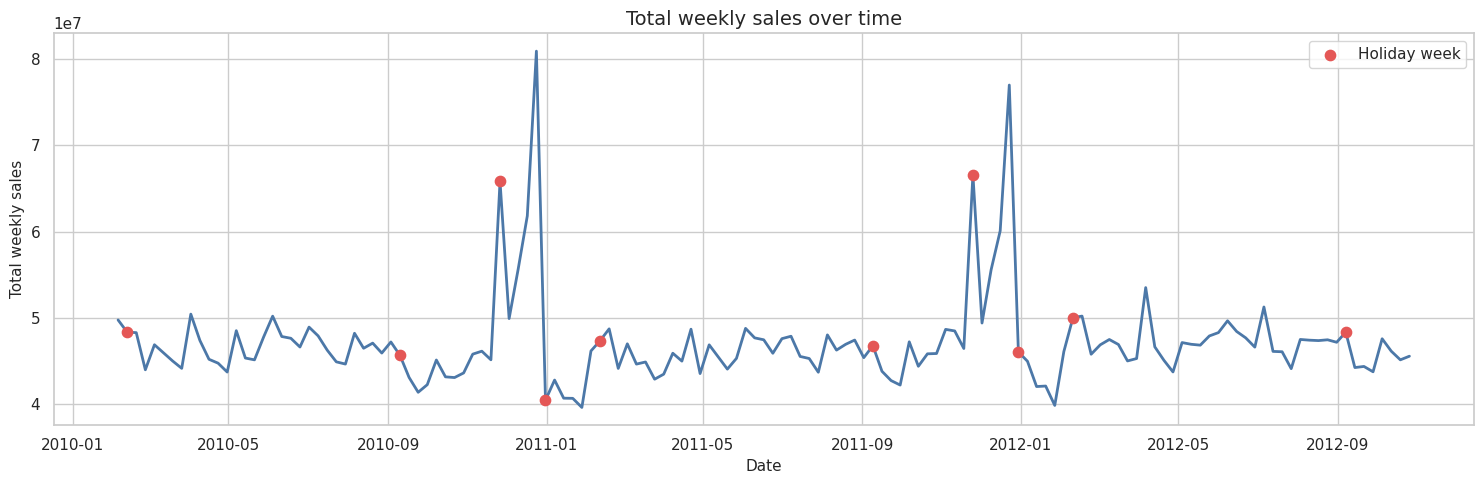

In [18]:
weekly_sales = (
    df.groupby("Date", as_index=False)
      .agg(Weekly_Sales=("Weekly_Sales", "sum"), IsHoliday=("IsHoliday", "max"))
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"], color="#4C78A8", linewidth=2)

holiday_weeks = weekly_sales[weekly_sales["IsHoliday"]]
ax.scatter(
    holiday_weeks["Date"], holiday_weeks["Weekly_Sales"],
    color="#E45756", s=55, label="Holiday week", zorder=3
)

ax.set_title("Total weekly sales over time")
ax.set_xlabel("Date")
ax.set_ylabel("Total weekly sales")
ax.legend()
plt.tight_layout()
plt.show()


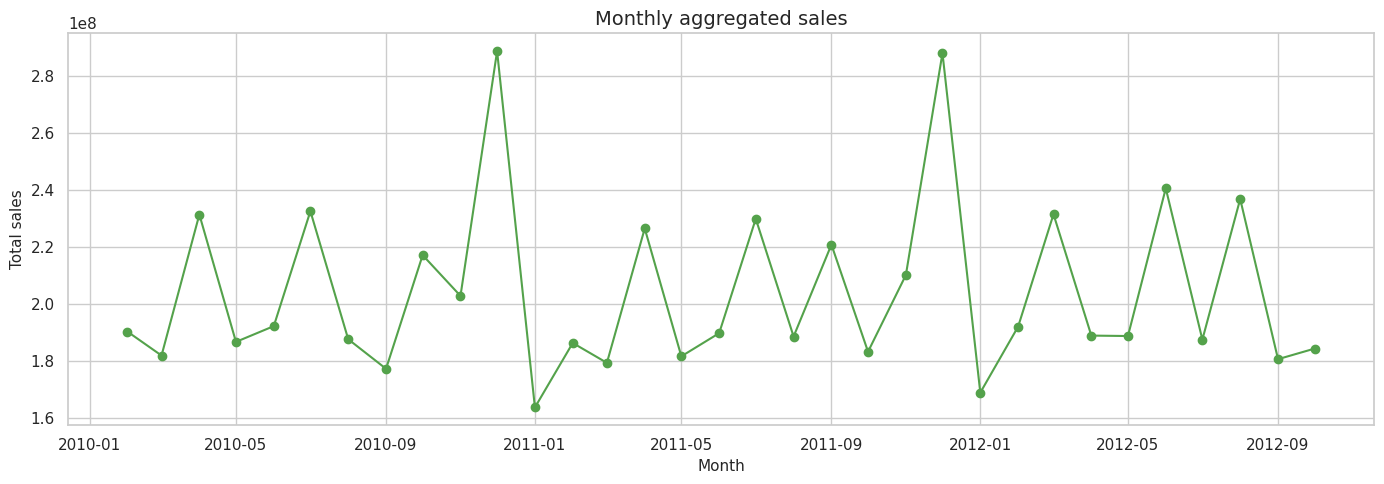

In [19]:
monthly_pattern = (
    df.groupby(["Year", "Month"], as_index=False)["Weekly_Sales"].sum()
)
monthly_pattern["Year_Month"] = pd.to_datetime(
    monthly_pattern["Year"].astype(str) + "-" + monthly_pattern["Month"].astype(str) + "-01"
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_pattern["Year_Month"], monthly_pattern["Weekly_Sales"], marker="o", color="#54A24B")
ax.set_title("Monthly aggregated sales")
ax.set_xlabel("Month")
ax.set_ylabel("Total sales")
plt.tight_layout()
plt.show()


##### Holiday effect
Kaggle uses weighted MAE, where holiday weeks have higher weight. So we should not only check if holidays increase sales, but also where they change sales the most.


In [20]:
holiday_summary = (
    df.groupby("IsHoliday")
      .agg(
          rows=("Weekly_Sales", "size"),
          mean_sales=("Weekly_Sales", "mean"),
          median_sales=("Weekly_Sales", "median"),
          total_sales=("Weekly_Sales", "sum")
      )
      .reset_index()
)
holiday_summary


,IsHoliday,rows,mean_sales,median_sales,total_sales
0,False,391909,"15,901.45","7,589.95","6,231,919,435.55"
1,True,29661,"17,035.82","7,947.74","505,299,551.56"


/tmp/ipykernel_3869/1065657680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_summary, x="IsHoliday", y="mean_sales", ax=axes[0], palette=["#72B7B2", "#E45756"])
/tmp/ipykernel_3869/1065657680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="IsHoliday", y="Weekly_Sales", ax=axes[1], showfliers=False, palette=["#72B7B2", "#E45756"])


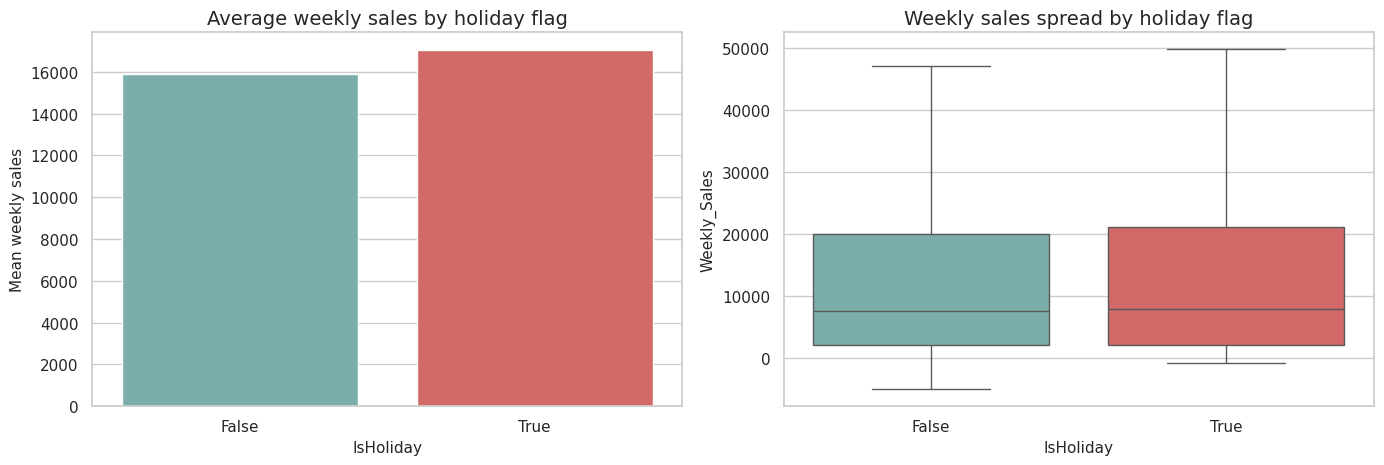

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if sns is not None:
    sns.barplot(data=holiday_summary, x="IsHoliday", y="mean_sales", ax=axes[0], palette=["#72B7B2", "#E45756"])
    sns.boxplot(data=df, x="IsHoliday", y="Weekly_Sales", ax=axes[1], showfliers=False, palette=["#72B7B2", "#E45756"])
else:
    axes[0].bar(holiday_summary["IsHoliday"].astype(str), holiday_summary["mean_sales"], color=["#72B7B2", "#E45756"])
    df.boxplot(column="Weekly_Sales", by="IsHoliday", ax=axes[1], showfliers=False)

axes[0].set_title("Average weekly sales by holiday flag")
axes[0].set_xlabel("IsHoliday")
axes[0].set_ylabel("Mean weekly sales")

axes[1].set_title("Weekly sales spread by holiday flag")
axes[1].set_xlabel("IsHoliday")
axes[1].set_ylabel("Weekly_Sales")
plt.suptitle("")
plt.tight_layout()
plt.show()


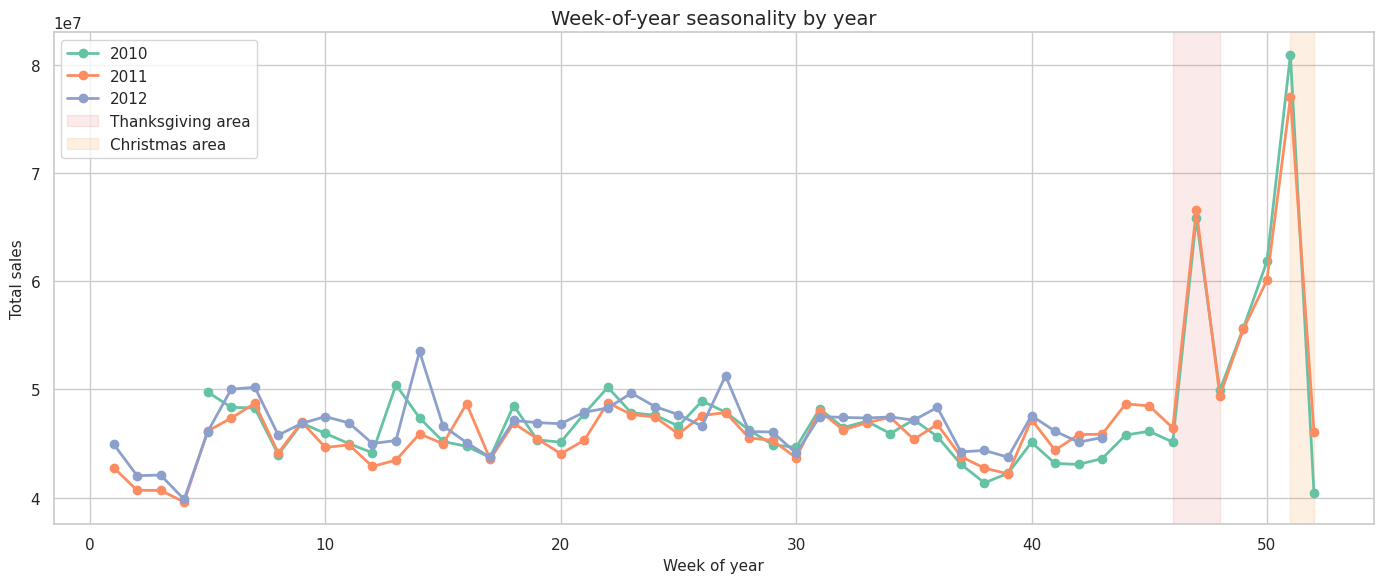

In [22]:
weekly_pivot = (
    df.groupby(["Week", "Year"], as_index=False)["Weekly_Sales"].sum()
      .pivot(index="Week", columns="Year", values="Weekly_Sales")
)

fig, ax = plt.subplots(figsize=(14, 6))
weekly_pivot.plot(ax=ax, marker="o", linewidth=2)
ax.set_title("Week-of-year seasonality by year")
ax.set_xlabel("Week of year")
ax.set_ylabel("Total sales")
ax.axvspan(46, 48, color="#E45756", alpha=0.12, label="Thanksgiving area")
ax.axvspan(51, 52, color="#F58518", alpha=0.12, label="Christmas area")
ax.legend()
plt.tight_layout()
plt.show()


##### Store type and size
Store type and size are static features. They look important, because bigger stores and Type A stores generally carry more total sales volume.


/tmp/ipykernel_3869/3947384126.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=store_summary, x="Type", y="total_sales", ax=axes[0], palette="Set2")


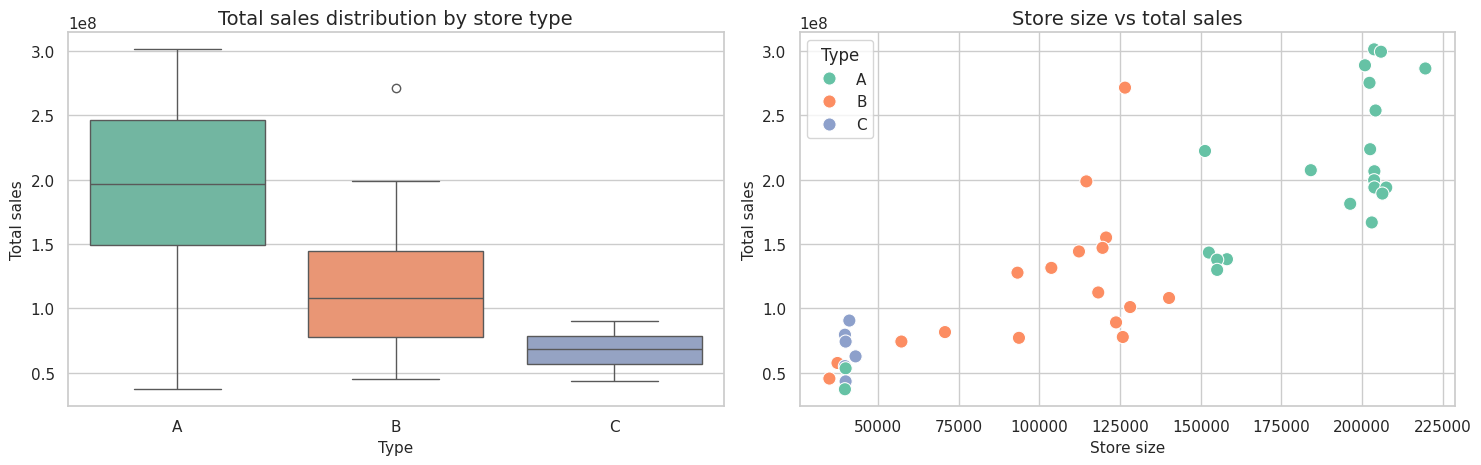

,Store,Type,Size,total_sales,mean_weekly_sales
19,20,A,203742,"301,397,792.46","29,508.30"
3,4,A,205863,"299,543,953.38","29,161.21"
13,14,A,200898,"288,999,911.34","28,784.85"
12,13,A,219622,"286,517,703.80","27,355.14"
1,2,A,202307,"275,382,440.98","26,898.07"
9,10,B,126512,"271,617,713.89","26,332.30"
26,27,A,204184,"253,855,916.88","24,826.98"
5,6,A,202505,"223,756,130.64","21,913.24"
0,1,A,151315,"222,402,808.85","21,710.54"
38,39,A,184109,"207,445,542.47","21,000.76"


In [23]:
store_summary = (
    df.groupby(["Store", "Type", "Size"], as_index=False)
      .agg(total_sales=("Weekly_Sales", "sum"), mean_weekly_sales=("Weekly_Sales", "mean"))
      .sort_values("total_sales", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if sns is not None:
    sns.boxplot(data=store_summary, x="Type", y="total_sales", ax=axes[0], palette="Set2")
    sns.scatterplot(data=store_summary, x="Size", y="total_sales", hue="Type", s=90, ax=axes[1], palette="Set2")
else:
    store_summary.boxplot(column="total_sales", by="Type", ax=axes[0])
    for store_type, part in store_summary.groupby("Type"):
        axes[1].scatter(part["Size"], part["total_sales"], s=90, label=store_type)
    axes[1].legend(title="Type")

axes[0].set_title("Total sales distribution by store type")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Total sales")

axes[1].set_title("Store size vs total sales")
axes[1].set_xlabel("Store size")
axes[1].set_ylabel("Total sales")

plt.suptitle("")
plt.tight_layout()
plt.show()

store_summary.head(10)


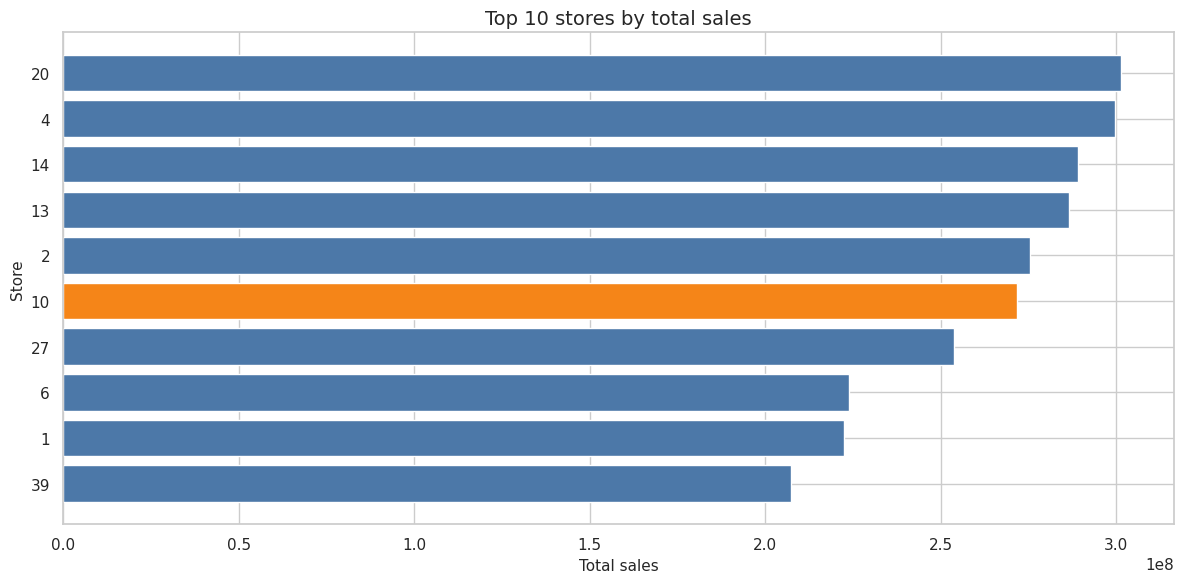

In [24]:
top_stores = store_summary.head(10).sort_values("total_sales")

fig, ax = plt.subplots(figsize=(12, 6))
colors = top_stores["Type"].map({"A": "#4C78A8", "B": "#F58518", "C": "#54A24B"})
ax.barh(top_stores["Store"].astype(str), top_stores["total_sales"], color=colors)
ax.set_title("Top 10 stores by total sales")
ax.set_xlabel("Total sales")
ax.set_ylabel("Store")
plt.tight_layout()
plt.show()


##### Department importance
We predict sales for Store-Dept combinations, but departments are very different from each other. Some departments have much higher volume and will be more important for the final error.


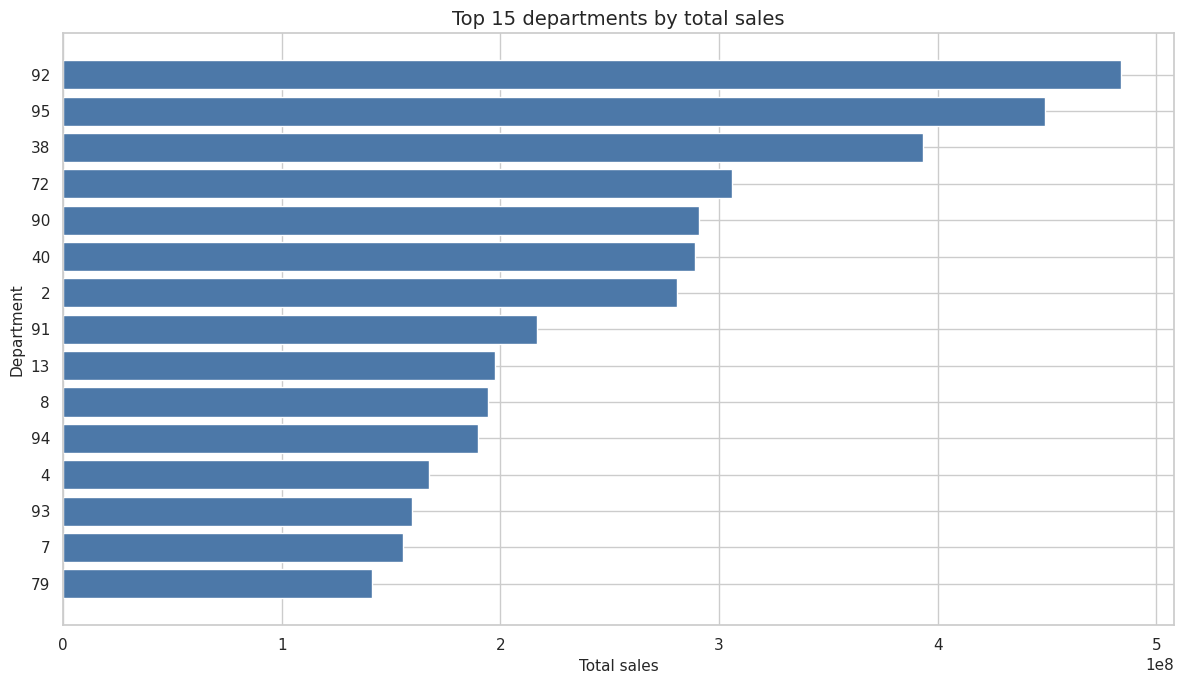

,Dept,total_sales,mean_sales,rows
73,92,"483,943,341.87","75,204.87",6435
76,95,"449,320,162.52","69,824.42",6435
36,38,"393,118,136.92","61,090.62",6435
60,72,"305,725,152.21","50,566.52",6046
71,90,"291,068,463.68","45,232.08",6435
38,40,"288,936,022.05","44,900.70",6435
1,2,"280,611,174.43","43,607.02",6435
72,91,"216,781,705.73","33,687.91",6435
12,13,"197,321,569.95","30,663.80",6435
7,8,"194,280,780.73","30,191.26",6435


In [25]:
dept_summary = (
    df.groupby("Dept", as_index=False)
      .agg(total_sales=("Weekly_Sales", "sum"), mean_sales=("Weekly_Sales", "mean"), rows=("Weekly_Sales", "size"))
      .sort_values("total_sales", ascending=False)
)

top_depts = dept_summary.head(15).sort_values("total_sales")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_depts["Dept"].astype(str), top_depts["total_sales"], color="#4C78A8")
ax.set_title("Top 15 departments by total sales")
ax.set_xlabel("Total sales")
ax.set_ylabel("Department")
plt.tight_layout()
plt.show()

dept_summary.head(15)


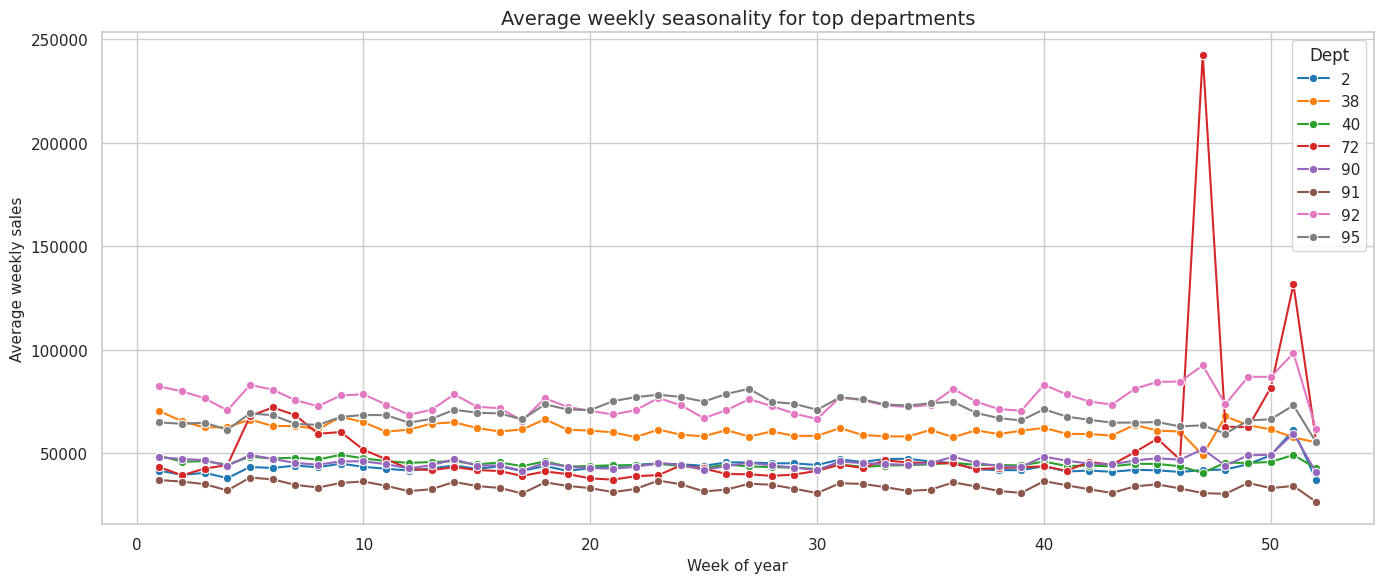

In [26]:
dept_week_pattern = (
    df[df["Dept"].isin(dept_summary.head(8)["Dept"])]
    .groupby(["Week", "Dept"], as_index=False)["Weekly_Sales"].mean()
)

fig, ax = plt.subplots(figsize=(14, 6))
if sns is not None:
    sns.lineplot(data=dept_week_pattern, x="Week", y="Weekly_Sales", hue="Dept", marker="o", ax=ax, palette="tab10")
else:
    for dept, part in dept_week_pattern.groupby("Dept"):
        ax.plot(part["Week"], part["Weekly_Sales"], marker="o", label=dept)
    ax.legend(title="Dept")

ax.set_title("Average weekly seasonality for top departments")
ax.set_xlabel("Week of year")
ax.set_ylabel("Average weekly sales")
plt.tight_layout()
plt.show()


##### Missing values and markdowns
MarkDown columns have a lot of missing values because markdown events started later. For tree models I can keep missingness as information, but for neural/statistical models we will need a clear imputation strategy.


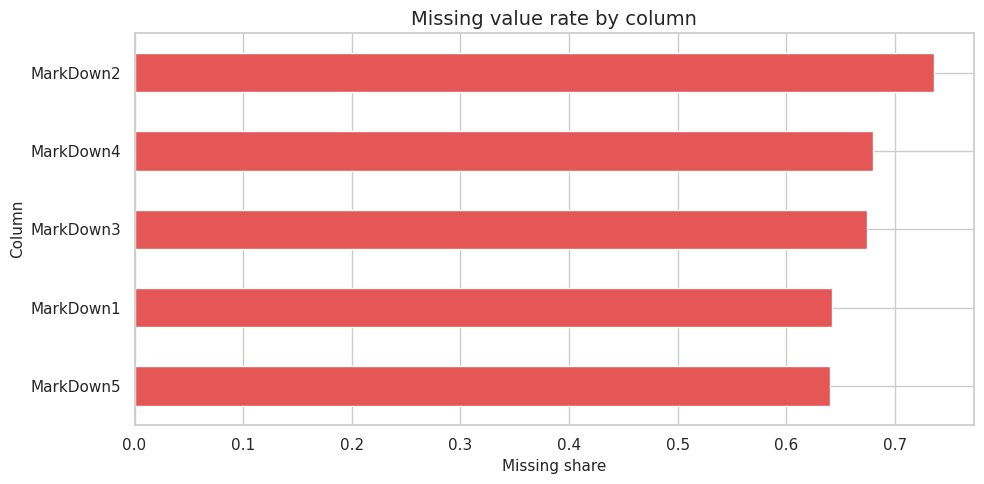

,0
MarkDown2,0.74
MarkDown4,0.68
MarkDown3,0.67
MarkDown1,0.64
MarkDown5,0.64


In [27]:
missing_rates = df.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing_rates[missing_rates > 0].sort_values().plot(kind="barh", ax=ax, color="#E45756")
ax.set_title("Missing value rate by column")
ax.set_xlabel("Missing share")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

missing_rates[missing_rates > 0]


##### Markdown availability over time
The previous markdown value chart starts when markdowns first have actual numeric values. To make the early missing period visible, here I plot the share of non-missing markdown values by date. Before late 2011 the availability is 0, which means markdown information was not present in the early training period.


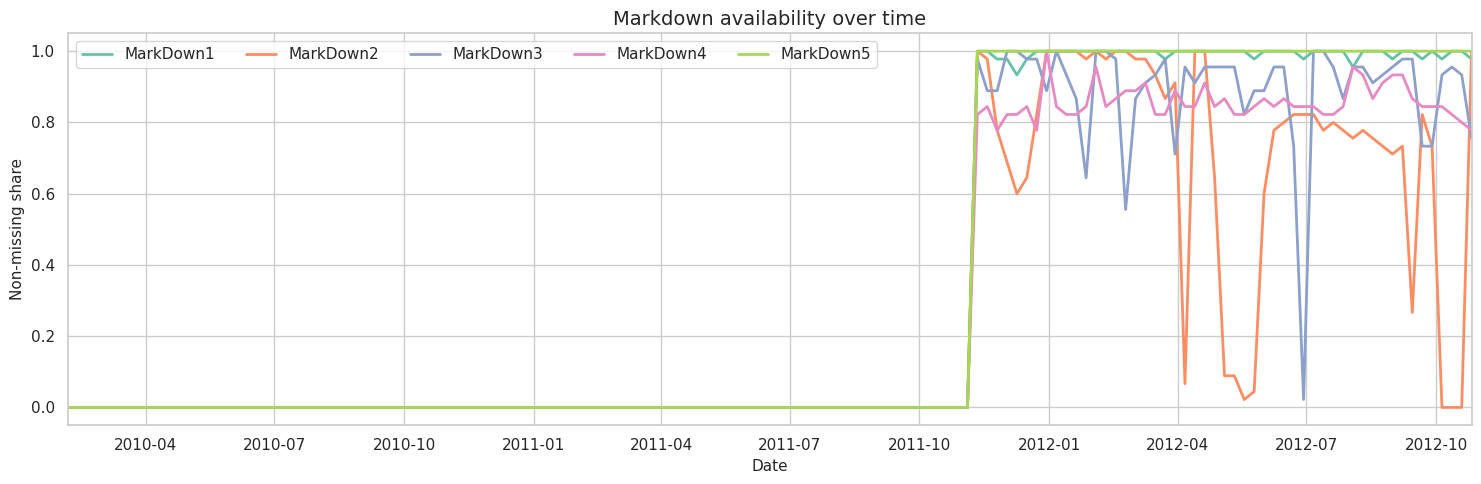

In [28]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
markdown_availability = features.copy()
markdown_availability["Date"] = pd.to_datetime(markdown_availability["Date"])
markdown_availability = (
    markdown_availability
    .groupby("Date")[markdown_cols]
    .agg(lambda x: x.notna().mean())
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 5))
for col in markdown_cols:
    ax.plot(markdown_availability["Date"], markdown_availability[col], label=col, linewidth=2)

ax.set_title("Markdown availability over time")
ax.set_xlabel("Date")
ax.set_ylabel("Non-missing share")
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(df["Date"].min(), df["Date"].max())
ax.legend(ncol=5)
plt.tight_layout()
plt.show()


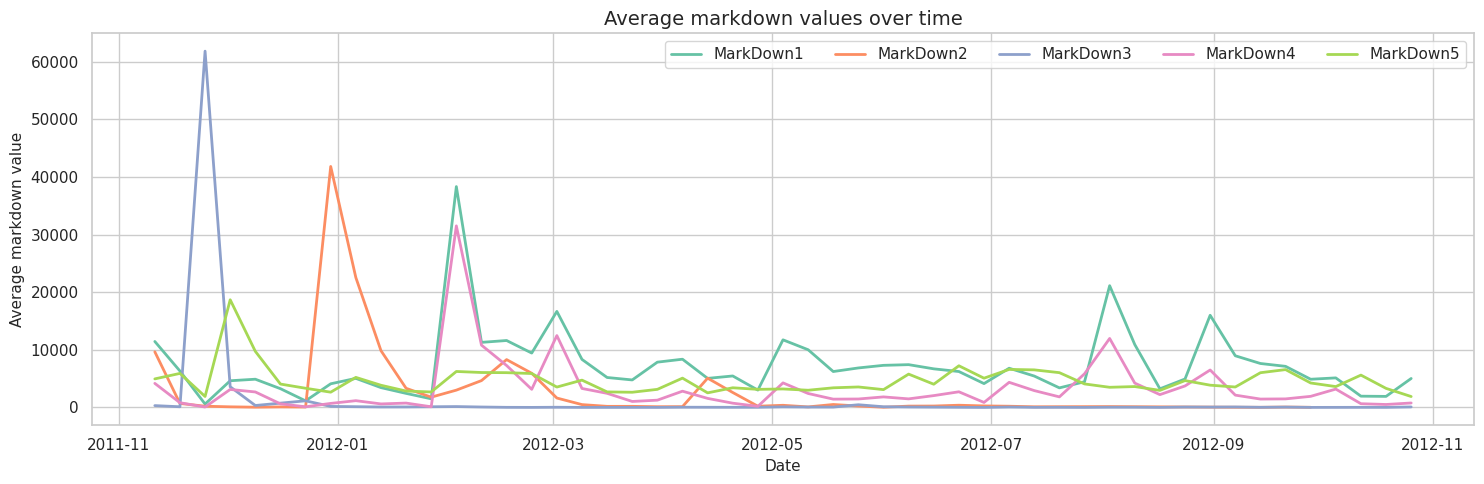

In [29]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
markdown_by_date = df.groupby("Date", as_index=False)[markdown_cols].mean()

fig, ax = plt.subplots(figsize=(15, 5))
for col in markdown_cols:
    ax.plot(markdown_by_date["Date"], markdown_by_date[col], label=col, linewidth=2)

ax.set_title("Average markdown values over time")
ax.set_xlabel("Date")
ax.set_ylabel("Average markdown value")
ax.legend(ncol=5)
plt.tight_layout()
plt.show()


In [30]:
df["Any_MarkDown"] = df[markdown_cols].notna().any(axis=1)
markdown_sales = (
    df.groupby("Any_MarkDown")
      .agg(rows=("Weekly_Sales", "size"), mean_sales=("Weekly_Sales", "mean"), median_sales=("Weekly_Sales", "median"))
      .reset_index()
)
markdown_sales


,Any_MarkDown,rows,mean_sales,median_sales
0,False,270138,"15,871.52","7,654.84"
1,True,151432,"16,177.02","7,537.87"


##### External feature relationships
These variables are available for train and test, so they are useful candidates for models. Correlation is not enough for forecasting, but it helps us see which variables move together.


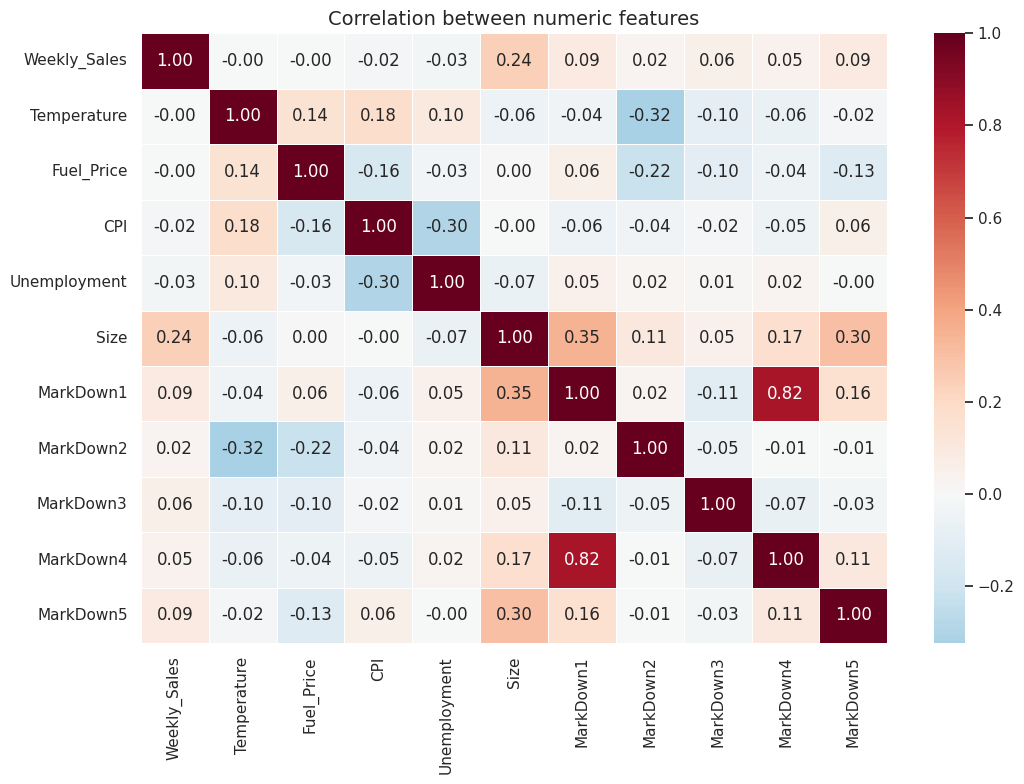

In [31]:
numeric_cols = [
    "Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Size",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
if sns is not None:
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
else:
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)), corr.index)
    fig.colorbar(im, ax=ax)

ax.set_title("Correlation between numeric features")
plt.tight_layout()
plt.show()


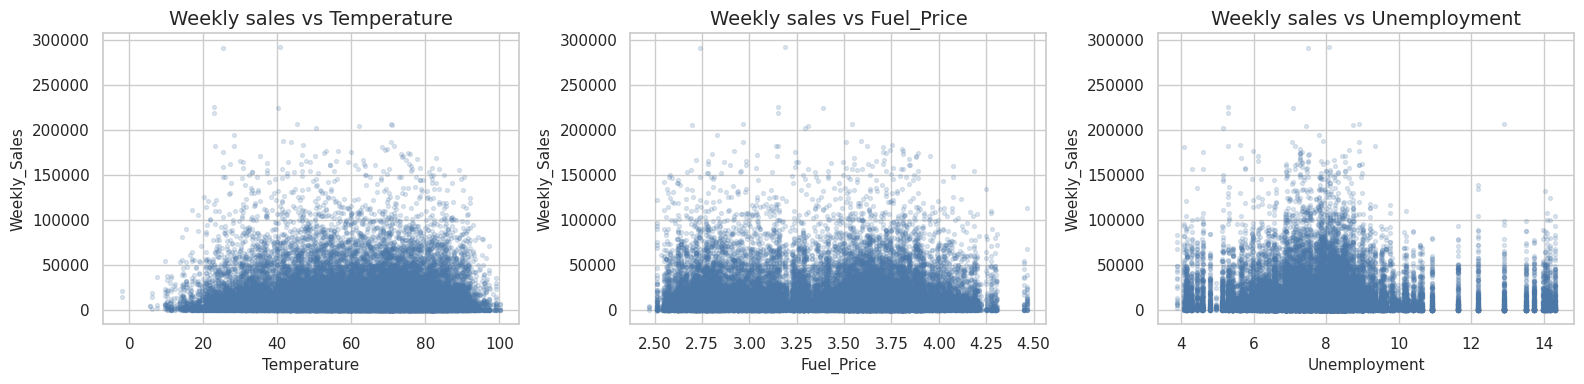

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
scatter_cols = ["Temperature", "Fuel_Price", "Unemployment"]

sample_df = df.sample(30000, random_state=42) if len(df) > 30000 else df
for ax, col in zip(axes, scatter_cols):
    ax.scatter(sample_df[col], sample_df["Weekly_Sales"], alpha=0.18, s=8, color="#4C78A8")
    ax.set_title(f"Weekly sales vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Weekly_Sales")

plt.tight_layout()
plt.show()


##### Train vs test structure
Before modeling I want to check that train and test have similar store/dept coverage. If some Store-Dept pairs only appear in test, lag-based features and per-series models need special handling.


In [33]:
train_pairs = set(zip(train["Store"], train["Dept"]))
test_pairs = set(zip(test["Store"], test["Dept"]))

print(f"Train Store-Dept pairs: {len(train_pairs):,}")
print(f"Test Store-Dept pairs: {len(test_pairs):,}")
print(f"Pairs only in train: {len(train_pairs - test_pairs):,}")
print(f"Pairs only in test: {len(test_pairs - train_pairs):,}")


Train Store-Dept pairs: 3,331
Test Store-Dept pairs: 3,169
Pairs only in train: 173
Pairs only in test: 11


In [34]:
coverage = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "stores": [train["Store"].nunique(), test["Store"].nunique()],
    "departments": [train["Dept"].nunique(), test["Dept"].nunique()],
    "store_dept_pairs": [len(train_pairs), len(test_pairs)],
    "min_date": [train["Date"].min(), test["Date"].min()],
    "max_date": [train["Date"].max(), test["Date"].max()],
})
coverage


,dataset,rows,stores,departments,store_dept_pairs,min_date,max_date
0,train,421570,45,81,3331,2010-02-05,2012-10-26
1,test,115064,45,81,3169,2012-11-02,2013-07-26


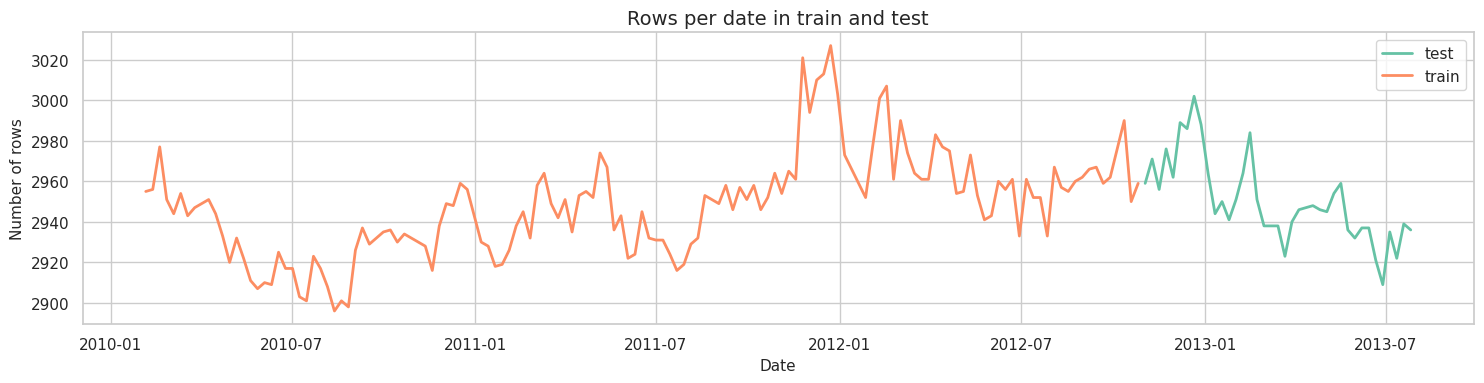

In [35]:
train_test_dates = pd.concat([
    train.assign(dataset="train")[["Date", "dataset"]],
    test.assign(dataset="test")[["Date", "dataset"]]
])

date_counts = train_test_dates.groupby(["Date", "dataset"]).size().reset_index(name="rows")

fig, ax = plt.subplots(figsize=(15, 4))
for dataset, part in date_counts.groupby("dataset"):
    ax.plot(part["Date"], part["rows"], label=dataset, linewidth=2)

ax.set_title("Rows per date in train and test")
ax.set_xlabel("Date")
ax.set_ylabel("Number of rows")
ax.legend()
plt.tight_layout()
plt.show()


##### main conclusions for next stages

1. This is a panel time-series problem: every Store-Dept pair is its own series, but stores also share calendar and external features.
2. Sales have strong yearly/holiday seasonality, so models need calendar features and a time-based validation split.
3. Holiday weeks matter more because the competition metric gives them higher weight.
4. Store Type/Size and Department are important explanatory features.
5. MarkDown variables are missing a lot, but this missingness is meaningful because markdowns begin later in the data.
6. For tree models we can use rich tabular features: lags, rolling means, calendar features, store/dept/category features and markdown indicators.
7. For deep learning/statistical models we need to be more careful with continuous time-series format, scaling, missing values and per-series history.
